In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 11.3 MB/s eta 0:00:00


In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score,mean_absolute_percentage_error
import matplotlib.pyplot as plt
import torch
import math
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import optuna

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [5]:
df = pd.read_csv('/content/drive/MyDrive/Yemen_Rainfall/Yemen_Rainfall_1982_2025.csv')
df

,Unnamed: 0,date,adm_level,adm_id,PCODE,n_pixels,rfh,rfh_avg,r1h,r1h_avg,r3h,r3h_avg,rfq,r1q,r3q,version,month,dekad,year
0,454320,1982-01-01,2,32878,0,24.0,1.000000,1.043055,4.000000,3.880556,9.833333,14.137500,99.287520,101.34500,77.509250,final,1,1,1982
1,478770,1982-01-01,2,32893,1,19.0,1.157895,1.049123,4.157895,4.145614,9.263158,13.300000,101.798140,100.13426,77.940760,final,1,1,1982
2,455950,1982-01-01,2,32879,2,10.0,1.000000,1.023333,4.000000,4.253334,9.400000,12.836667,99.612610,97.26224,80.732574,final,1,1,1982
3,457580,1982-01-01,2,32880,3,9.0,1.000000,1.003704,4.000000,4.166666,9.888889,13.162963,99.938310,98.18182,81.973900,final,1,1,1982
4,464100,1982-01-01,2,32884,4,6.0,1.000000,1.055556,4.000000,4.094444,10.000000,13.688889,99.082570,98.96152,80.261600,final,1,1,1982
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
503707,277333,2025-12-21,2,145040,313,7.0,2.000000,1.652381,4.285714,4.523809,12.142858,17.409523,105.225480,97.50000,76.498085,final,12,21,2025
503708,273655,2025-12-21,2,145039,314,9.0,2.000000,1.600000,4.000000,4.322222,12.444444,17.692593,106.060616,96.54351,76.872850,final,12,21,2025
503709,292463,2025-12-21,2,999528,315,10.0,1.800000,1.570000,4.600000,4.146667,17.800000,21.576668,103.500770,104.95627,85.789530,final,12,21,2025
503710,228307,2025-12-21,2,145016,316,88.0,14.522727,14.787121,34.545456,41.764393,58.613636,74.689390,98.663810,84.56318,79.826980,final,12,21,2025


In [6]:
df = df.drop(['rfq','r1q','r3q','rfh_avg','r1h_avg','r3h_avg','n_pixels','version','Unnamed: 0','adm_id', 'adm_level'], axis=1)
df = df.sort_values(by=['PCODE', 'year', 'month', 'dekad']).reset_index(drop=True)
df

,date,PCODE,rfh,r1h,r3h,month,dekad,year
0,1982-01-01,0,1.000000,4.000000,9.833333,1,1,1982
1,1982-01-11,0,3.000000,6.000000,12.000000,1,11,1982
2,1982-01-21,0,1.000000,5.000000,12.000000,1,21,1982
3,1982-02-01,0,1.000000,5.000000,12.000000,2,1,1982
4,1982-02-11,0,3.583333,5.583333,14.583333,2,11,1982
...,...,...,...,...,...,...,...,...
503707,2025-11-11,317,5.289473,10.289474,12.657895,11,11,2025
503708,2025-11-21,317,6.394737,15.473684,18.789474,11,21,2025
503709,2025-12-01,317,7.710527,19.394737,26.184212,12,1,2025
503710,2025-12-11,317,11.842105,25.947369,37.710526,12,11,2025


In [7]:
lags = [1, 2, 3, 6, 12]

def create_lags(df):
    df = df.sort_values(['PCODE','year','month','dekad'])

    for lag in [1,2,3,6,12]:
        df[f'rfh_lag_{lag}'] = df.groupby('PCODE')['rfh'].shift(lag)

    return df

df = create_lags(df)
df = df.dropna()

In [8]:
df['PCODE'] = df['PCODE'].astype('category').cat.codes

In [9]:
df['month_sin'] = np.sin(2*np.pi*df['month']/12)
df['month_cos'] = np.cos(2*np.pi*df['month']/12)

df['dekad_sin'] = np.sin(2*np.pi*df['dekad']/3)
df['dekad_cos'] = np.cos(2*np.pi*df['dekad']/3)

In [10]:
df.columns

Index(['date', 'PCODE', 'rfh', 'r1h', 'r3h', 'month', 'dekad', 'year',
       'rfh_lag_1', 'rfh_lag_2', 'rfh_lag_3', 'rfh_lag_6', 'rfh_lag_12',
       'month_sin', 'month_cos', 'dekad_sin', 'dekad_cos'],
      dtype='object')

In [11]:
df_log = df.copy()

cols = ['rfh', 'r1h', 'r3h']
for col in cols:
    df_log[col] = np.log1p(df_log[col])

In [12]:
final_features = [
    'rfh','r1h','r3h',
    'rfh_lag_1','rfh_lag_2','rfh_lag_3','rfh_lag_6','rfh_lag_12',
    'month_sin', 'month_cos', 'dekad_sin', 'dekad_cos',
    'month','dekad'
]
target = 'rfh'

In [13]:
train_df = df_log[df_log['date'] <= '2015-12-31']
val_df   = df_log[(df_log['date'] > '2015-12-31') & (df_log['date'] <= '2020-12-31')]
test_df  = df_log[df_log['date'] > '2020-12-31']

In [14]:
from sklearn.preprocessing import MinMaxScaler

x_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

train_df.loc[:, final_features] = x_scaler.fit_transform(train_df[final_features])
val_df.loc[:, final_features]   = x_scaler.transform(val_df[final_features])
test_df.loc[:, final_features]  = x_scaler.transform(test_df[final_features])

train_df.loc[:, target] = y_scaler.fit_transform(train_df[[target]])
val_df.loc[:, target]   = y_scaler.transform(val_df[[target]])
test_df.loc[:, target]  = y_scaler.transform(test_df[[target]])

/tmp/ipykernel_7036/7794158.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.36363636 0.36363636 0.36363636 ... 1.         1.         1.        ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[:, final_features] = x_scaler.fit_transform(train_df[final_features])
/tmp/ipykernel_7036/7794158.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.  0.5 1.  ... 0.  0.5 1. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_df.loc[:, final_features] = x_scaler.fit_transform(train_df[final_features])
/tmp/ipykernel_7036/7794158.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0. 0. 0. ... 1. 1. 1.]' has dtype incompatible with int64, please explicitly cast to a compatib

In [15]:
def create_sequences_per_pcode(df, features, target, seq_len=24):
    X_list, y_list, pcode_list = [], [], []

    for pcode, group in df.groupby('PCODE'):
        group = group.sort_values(['year','month','dekad'])

        X = group[features].values
        y = group[target].values

        for i in range(len(group) - seq_len):
            X_list.append(X[i:i+seq_len])
            y_list.append(y[i+seq_len])
            pcode_list.append(pcode)

    return (
        torch.tensor(X_list, dtype=torch.float32),
        torch.tensor(y_list, dtype=torch.float32),
        torch.tensor(pcode_list, dtype=torch.long)
    )

In [16]:
X_train, y_train, p_train = create_sequences_per_pcode(train_df, final_features, target, seq_len=24)
X_val, y_val, p_val       = create_sequences_per_pcode(val_df, final_features, target, seq_len=24)
X_test, y_test, p_test    = create_sequences_per_pcode(test_df, final_features, target, seq_len=24)

/tmp/ipykernel_7036/103391394.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  torch.tensor(X_list, dtype=torch.float32),


In [17]:
train_ds = TensorDataset(X_train, y_train, p_train)
val_ds   = TensorDataset(X_val, y_val, p_val)
test_ds  = TensorDataset(X_test, y_test, p_test)

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=256, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=256, shuffle=False, pin_memory=True)

In [18]:
class iTransformer(nn.Module):
    def __init__(
        self,
        num_features,      # 14
        seq_len,           # 24
        num_pcodes,        # 318
        d_model=128,
        n_heads=4,
        num_layers=3,
        d_ff=256,
        dropout=0.1,
        pcode_embed_dim=16
    ):
        super().__init__()

        # 1. PCODE embedding
        self.pcode_emb = nn.Embedding(num_pcodes, pcode_embed_dim)

        # 2. Inverted embedding (Time → Representation)
        self.value_embedding = nn.Linear(seq_len, d_model)

        # 3. Feature (token) embedding
        self.feature_embedding = nn.Parameter(
            torch.randn(1, num_features, d_model)
        )

        # 4. Combine dim
        self.total_dim = d_model + pcode_embed_dim

        # 5. Transformer Encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=self.total_dim,
            nhead=n_heads,
            dim_feedforward=d_ff,
            dropout=dropout,
            batch_first=True,
            activation='gelu'
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers)

        # 6. LayerNorm
        self.norm = nn.LayerNorm(self.total_dim)

        # 7. Prediction head
        self.head = nn.Sequential(
            nn.Linear(self.total_dim, 64),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x, pcode):
        # x: (B, T, F)

        B, T, F = x.shape

        # 1. Invert → (B, F, T)
        x = x.permute(0, 2, 1)

        # 2. Project time → representation
        x = self.value_embedding(x)  # (B, F, d_model)

        # 3. Add feature embedding (VERY IMPORTANT - paper detail)
        x = x + self.feature_embedding

        # 4. PCODE embedding
        p_emb = self.pcode_emb(pcode)  # (B, E)
        p_emb = p_emb.unsqueeze(1).expand(-1, F, -1)

        # 5. Concatenate
        x = torch.cat([x, p_emb], dim=-1)

        # 6. Normalize
        x = self.norm(x)

        # 7. Transformer (attention across FEATURES)
        x = self.encoder(x)

        # 8. Aggregation (mean over features)
        x = x.mean(dim=1)

        # 9. Prediction
        out = self.head(x)

        return out.squeeze()

In [19]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for X, y, p in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        p = p.to(device, non_blocking=True)

        optimizer.zero_grad()
        out = model(X, p)
        loss = criterion(out, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def validate(model, loader, criterion):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for X, y, p in loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)
            p = p.to(device, non_blocking=True)

            out = model(X, p)
            loss = criterion(out, y)

            total_loss += loss.item()

    return total_loss / len(loader)

In [20]:
def objective(trial):

    # Search space (paper-style)
    d_model = trial.suggest_categorical("d_model", [64, 128, 256])
    n_heads = trial.suggest_categorical("n_heads", [2, 4, 8])
    num_layers = trial.suggest_int("num_layers", 2, 4)
    d_ff = trial.suggest_categorical("d_ff", [128, 256, 512])
    dropout = trial.suggest_float("dropout", 0.1, 0.3)
    pcode_embed_dim = trial.suggest_categorical("pcode_embed_dim", [8, 16, 32])
    lr = trial.suggest_float("lr", 1e-4, 1e-3, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    # Model
    model = iTransformer(
        num_features=14,
        seq_len=24,
        num_pcodes=318,
        d_model=d_model,
        n_heads=n_heads,
        num_layers=num_layers,
        d_ff=d_ff,
        dropout=dropout,
        pcode_embed_dim=pcode_embed_dim
    ).to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.MSELoss()

    best_val = float("inf")
    patience = 5
    patience_counter = 0

    # Training loop
    for epoch in range(30):  #

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss   = validate(model, val_loader, criterion)

        trial.report(val_loss, epoch)

        # Early stopping
        if val_loss < best_val:
            best_val = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

        # Pruning (Optuna magic )
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

    return best_val

In [21]:
study = optuna.create_study(direction="minimize")

study.optimize(objective, n_trials=20)

print("Best Trial:")
print(study.best_trial.params)

[I 2026-04-12 15:28:29,764] A new study created in memory with name: no-name-311d50e7-e9e9-47ae-ae09-33bc1b714b0f
[I 2026-04-12 15:32:29,781] Trial 0 finished with value: 0.006828521165910379 and parameters: {'d_model': 64, 'n_heads': 8, 'num_layers': 2, 'd_ff': 512, 'dropout': 0.23808748081120645, 'pcode_embed_dim': 8, 'lr': 0.00017944500324297615, 'weight_decay': 0.00016949568490634597}. Best is trial 0 with value: 0.006828521165910379.
[I 2026-04-12 15:37:55,261] Trial 1 finished with value: 0.006627807950543374 and parameters: {'d_model': 64, 'n_heads': 4, 'num_layers': 2, 'd_ff': 128, 'dropout': 0.24385594597057295, 'pcode_embed_dim': 8, 'lr': 0.00015204851000866134, 'weight_decay': 1.8023872957422705e-05}. Best is trial 1 with value: 0.006627807950543374.
[I 2026-04-12 15:42:01,454] Trial 2 finished with value: 0.006564600173547173 and parameters: {'d_model': 64, 'n_heads': 2, 'num_layers': 3, 'd_ff': 256, 'dropout': 0.28205327032412786, 'pcode_embed_dim': 16, 'lr': 0.00025561074

Best Trial:
{'d_model': 64, 'n_heads': 2, 'num_layers': 3, 'd_ff': 256, 'dropout': 0.28205327032412786, 'pcode_embed_dim': 16, 'lr': 0.00025561074259545017, 'weight_decay': 0.00029674276190524084}


In [22]:
best_params = study.best_trial.params

model = iTransformer(
    num_features=14,
    seq_len=24,
    num_pcodes=318,
    d_model=best_params["d_model"],
    n_heads=best_params["n_heads"],
    num_layers=best_params["num_layers"],
    d_ff=best_params["d_ff"],
    dropout=best_params["dropout"],
    pcode_embed_dim=best_params["pcode_embed_dim"]
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=best_params["lr"],
    weight_decay=best_params["weight_decay"]
)

criterion = nn.MSELoss()

In [23]:
best_val = float("inf")

for epoch in range(50):

    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss   = validate(model, val_loader, criterion)

    print(f"Epoch {epoch+1} | Train {train_loss:.4f} | Val {val_loss:.4f}")

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "best_itransformer.pth")

Epoch 1 | Train 0.0158 | Val 0.0092
Epoch 2 | Train 0.0092 | Val 0.0081
Epoch 3 | Train 0.0083 | Val 0.0077
Epoch 4 | Train 0.0078 | Val 0.0077
Epoch 5 | Train 0.0074 | Val 0.0073
Epoch 6 | Train 0.0071 | Val 0.0072
Epoch 7 | Train 0.0068 | Val 0.0072
Epoch 8 | Train 0.0066 | Val 0.0069
Epoch 9 | Train 0.0065 | Val 0.0068
Epoch 10 | Train 0.0063 | Val 0.0073
Epoch 11 | Train 0.0062 | Val 0.0074
Epoch 12 | Train 0.0061 | Val 0.0069
Epoch 13 | Train 0.0060 | Val 0.0073
Epoch 14 | Train 0.0059 | Val 0.0073
Epoch 15 | Train 0.0058 | Val 0.0070
Epoch 16 | Train 0.0057 | Val 0.0075
Epoch 17 | Train 0.0057 | Val 0.0073
Epoch 18 | Train 0.0056 | Val 0.0074
Epoch 19 | Train 0.0055 | Val 0.0073
Epoch 20 | Train 0.0054 | Val 0.0076
Epoch 21 | Train 0.0054 | Val 0.0076
Epoch 22 | Train 0.0053 | Val 0.0077
Epoch 23 | Train 0.0052 | Val 0.0078
Epoch 24 | Train 0.0051 | Val 0.0082
Epoch 25 | Train 0.0051 | Val 0.0078
Epoch 26 | Train 0.0050 | Val 0.0082
Epoch 27 | Train 0.0049 | Val 0.0082
Epoch 28 |

In [24]:
model.load_state_dict(torch.load("best_itransformer.pth"))
model.eval()

preds, actuals = [], []

with torch.no_grad():
    for X, y, p in test_loader:
        X = X.to(device)
        p = p.to(device)

        out = model(X, p)

        preds.append(out.cpu().numpy())
        actuals.append(y.numpy())

preds = np.concatenate(preds).reshape(-1, 1)
actuals = np.concatenate(actuals).reshape(-1, 1)

# Inverse scaling
preds = y_scaler.inverse_transform(preds)
actuals = y_scaler.inverse_transform(actuals)

In [25]:
rmse = np.sqrt(mean_squared_error(actuals, preds))
mae  = mean_absolute_error(actuals, preds)
r2   = r2_score(actuals, preds)

print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")

RMSE: 0.0896
MAE : 0.0637
R2  : 0.7648


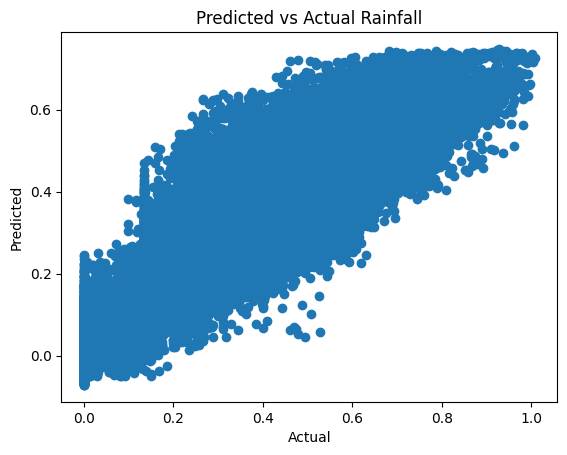

In [26]:
plt.figure()
plt.scatter(actuals, preds)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual Rainfall")
plt.show()

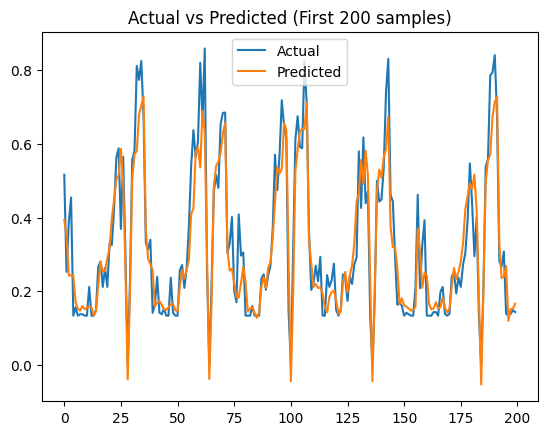

In [27]:
plt.figure()
plt.plot(actuals[:200], label="Actual")
plt.plot(preds[:200], label="Predicted")
plt.legend()
plt.title("Actual vs Predicted (First 200 samples)")
plt.show()

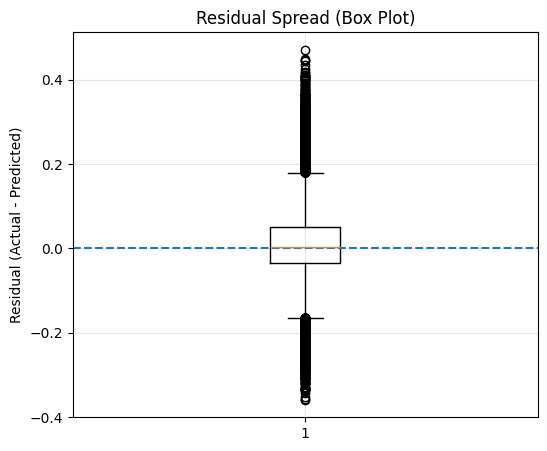

In [28]:
y_true = np.array(actuals).flatten()
y_pred = np.array(preds).flatten()

# Residuals
residuals = y_true - y_pred

plt.figure(figsize=(6,5))

plt.boxplot(residuals, vert=True)

# zero reference line
plt.axhline(0, linestyle='--')

plt.title("Residual Spread (Box Plot)")
plt.ylabel("Residual (Actual - Predicted)")

plt.grid(alpha=0.3)

plt.savefig("residual_boxplot.png", dpi=300)
plt.show()

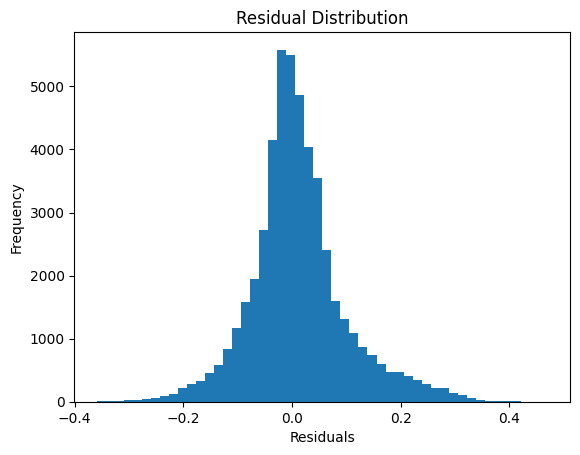

In [29]:
residuals = np.array(actuals) - np.array(preds)

plt.figure()
plt.hist(residuals, bins=50)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

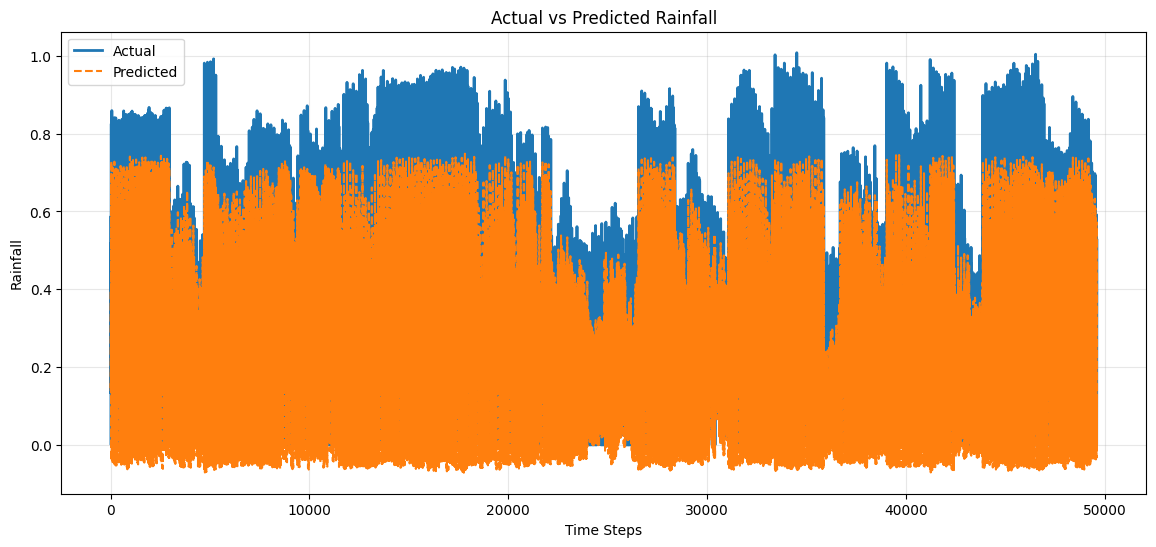

In [30]:
y_true = np.array(actuals).flatten()
y_pred = np.array(preds).flatten()

plt.figure(figsize=(14,6))

plt.plot(y_true, label="Actual", linewidth=2)
plt.plot(y_pred, label="Predicted", linestyle='--')

plt.title("Actual vs Predicted Rainfall")
plt.xlabel("Time Steps")
plt.ylabel("Rainfall")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

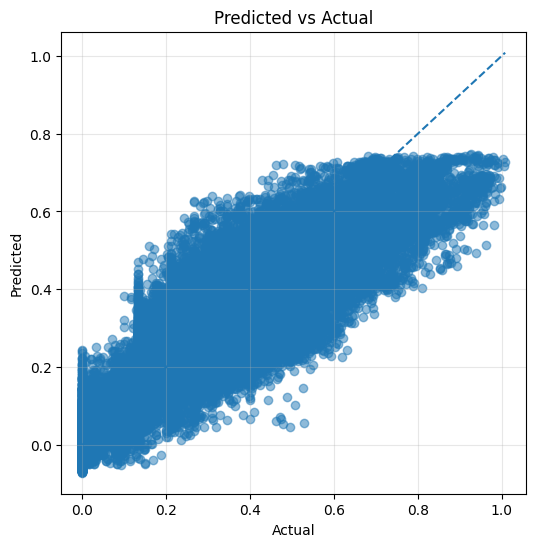

In [31]:
plt.figure(figsize=(6,6))

plt.scatter(y_true, y_pred, alpha=0.5)

# perfect prediction line
plt.plot([y_true.min(), y_true.max()],
         [y_true.min(), y_true.max()],
         linestyle='--')

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")

plt.grid(alpha=0.3)

plt.show()

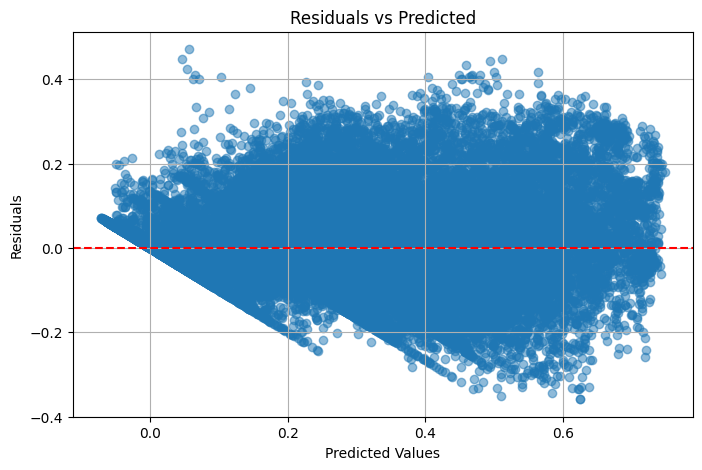

In [32]:
plt.figure(figsize=(8,5))
plt.scatter(preds, residuals, alpha=0.5)

plt.axhline(0, color='r', linestyle='--')

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")

plt.grid(True)
plt.show()

In [34]:
print(actuals.shape)
print(preds.shape)

(49608, 1)
(49608, 1)


In [36]:
results = pd.DataFrame({
    "actual": actuals.ravel(),
    "pred": preds.ravel()
})
results.to_csv("iTransformer_results.csv", index=False)